# 🧹 Data Cleaning Project
## Oasis Infobyte — Data Analytics Internship
### Level 1 | Project 3

**Intern:** Maddali Naga Durga Niharika  
**College:** VVIT  
**Domain:** Data Analytics  

---

### 📌 Objective
To clean and preprocess two real-world datasets by handling missing values,
removing duplicates, standardizing formats, and detecting outliers —
ensuring data integrity for reliable analysis.

### 📂 Datasets Used
| # | Dataset | Source |
|---|---------|--------|
| 1 | New York City Airbnb Open Data | Kaggle |
| 2 | Trending YouTube Video Statistics | Kaggle |

### 🛠️ Tools & Libraries
`Python` `Pandas` `NumPy` `Matplotlib` `Seaborn` `Google Colab`

In [3]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns        # Statistical plots
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# ============================================================
# STEP 2: Upload Datasets
# ============================================================

from google.colab import files

print("📂 Please upload: AB_NYC_2019.csv and USvideos.csv")
uploaded = files.upload()
print("\n✅ Files uploaded:", list(uploaded.keys()))

📂 Please upload: AB_NYC_2019.csv and USvideos.csv


Saving AB_NYC_2019.csv to AB_NYC_2019.csv
Saving USvideos.csv to USvideos.csv

✅ Files uploaded: ['AB_NYC_2019.csv', 'USvideos.csv']


In [5]:
# ============================================================
# STEP 3: Load Datasets into DataFrames
# ============================================================

import io

# --- Dataset 1: NYC Airbnb ---
df1 = pd.read_csv(io.BytesIO(uploaded['AB_NYC_2019.csv']))
print("=" * 50)
print("📊 Dataset 1: NYC Airbnb Open Data")
print(f"   Rows: {df1.shape[0]:,} | Columns: {df1.shape[1]}")

# --- Dataset 2: YouTube Trending Videos ---
df2 = pd.read_csv(io.BytesIO(uploaded['USvideos.csv']), encoding='latin-1')
print("=" * 50)
print("📊 Dataset 2: Trending YouTube Video Statistics")
print(f"   Rows: {df2.shape[0]:,} | Columns: {df2.shape[1]}")
print("=" * 50)
print("\n✅ Both datasets loaded successfully!")

📊 Dataset 1: NYC Airbnb Open Data
   Rows: 48,895 | Columns: 16
📊 Dataset 2: Trending YouTube Video Statistics
   Rows: 40,949 | Columns: 16

✅ Both datasets loaded successfully!


In [6]:
# ============================================================
# STEP 4A: Explore Dataset 1 — NYC Airbnb
# ============================================================

print("=" * 50)
print("📊 AIRBNB DATASET — OVERVIEW")
print("=" * 50)

print("\n🔹 First 5 Rows:")
display(df1.head())

print("\n🔹 Missing Values:")
missing1 = df1.isnull().sum()
missing_pct1 = (df1.isnull().sum() / len(df1) * 100).round(2)
missing_df1 = pd.DataFrame({
    'Missing Count': missing1,
    'Missing %': missing_pct1
}).query('`Missing Count` > 0')
print(missing_df1)

print(f"\n🔹 Duplicate Rows: {df1.duplicated().sum()}")

print("\n🔹 Statistical Summary:")
display(df1.describe())

📊 AIRBNB DATASET — OVERVIEW

🔹 First 5 Rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



🔹 Missing Values:
                   Missing Count  Missing %
name                          16       0.03
host_name                     21       0.04
last_review                10052      20.56
reviews_per_month          10052      20.56

🔹 Duplicate Rows: 0

🔹 Statistical Summary:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
# ============================================================
# STEP 4B: Explore Dataset 2 — YouTube Trending Videos
# ============================================================

print("=" * 50)
print("📊 YOUTUBE DATASET — OVERVIEW")
print("=" * 50)

print("\n🔹 First 5 Rows:")
display(df2.head())

print("\n🔹 Missing Values:")
missing2 = df2.isnull().sum()
missing_pct2 = (df2.isnull().sum() / len(df2) * 100).round(2)
missing_df2 = pd.DataFrame({
    'Missing Count': missing2,
    'Missing %': missing_pct2
}).query('`Missing Count` > 0')
print(missing_df2)

print(f"\n🔹 Duplicate Rows: {df2.duplicated().sum()}")

print("\n🔹 Statistical Summary:")
display(df2.describe())

📊 YOUTUBE DATASET — OVERVIEW

🔹 First 5 Rows:


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...



🔹 Missing Values:
             Missing Count  Missing %
description            570       1.39

🔹 Duplicate Rows: 48

🔹 Statistical Summary:


,category_id,views,likes,dislikes,comment_count
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


In [9]:
# ============================================================
# STEP 5A: Clean Dataset 1 — NYC Airbnb
# ============================================================

df1_clean = df1.copy()  # Always work on a copy!

# --- 1. Handle Missing Values ---
df1_clean['name'].fillna('Unknown', inplace=True)
df1_clean['host_name'].fillna('Unknown', inplace=True)
df1_clean['reviews_per_month'].fillna(0, inplace=True)
df1_clean['last_review'].fillna('No Review', inplace=True)

# --- 2. Remove Duplicates ---
before = df1_clean.shape[0]
df1_clean.drop_duplicates(inplace=True)
after = df1_clean.shape[0]

# --- 3. Standardize Text Columns ---
df1_clean['room_type'] = df1_clean['room_type'].str.strip().str.lower()
df1_clean['neighbourhood_group'] = df1_clean['neighbourhood_group'].str.strip().str.title()
df1_clean['neighbourhood'] = df1_clean['neighbourhood'].str.strip().str.title()

# --- 4. Fix Data Types ---
df1_clean['price'] = pd.to_numeric(df1_clean['price'], errors='coerce')

# --- Summary ---
print("=" * 50)
print("✅ AIRBNB DATASET — CLEANING COMPLETE")
print("=" * 50)
print(f"  Duplicates Removed : {before - after}")
print(f"  Missing Values Left: {df1_clean.isnull().sum().sum()}")
print(f"  Final Shape        : {df1_clean.shape}")

✅ AIRBNB DATASET — CLEANING COMPLETE
  Duplicates Removed : 0
  Missing Values Left: 0
  Final Shape        : (48895, 16)


In [10]:
# ============================================================
# STEP 5B: Clean Dataset 2 — YouTube Trending Videos
# ============================================================

df2_clean = df2.copy()  # Always work on a copy!

# --- 1. Handle Missing Values ---
df2_clean['description'].fillna('No Description', inplace=True)
df2_clean['tags'].fillna('No Tags', inplace=True)

# --- 2. Remove Duplicates ---
before2 = df2_clean.shape[0]
df2_clean.drop_duplicates(inplace=True)
after2 = df2_clean.shape[0]

# --- 3. Standardize Text ---
df2_clean['title'] = df2_clean['title'].str.strip()
df2_clean['channel_title'] = df2_clean['channel_title'].str.strip()

# --- 4. Fix Date Column ---
df2_clean['trending_date'] = pd.to_datetime(
    df2_clean['trending_date'], format='%y.%d.%m', errors='coerce'
)

# --- 5. Fix Numeric Columns ---
for col in ['views', 'likes', 'dislikes', 'comment_count']:
    df2_clean[col] = pd.to_numeric(df2_clean[col], errors='coerce')

# --- Summary ---
print("=" * 50)
print("✅ YOUTUBE DATASET — CLEANING COMPLETE")
print("=" * 50)
print(f"  Duplicates Removed : {before2 - after2}")
print(f"  Missing Values Left: {df2_clean.isnull().sum().sum()}")
print(f"  Final Shape        : {df2_clean.shape}")

✅ YOUTUBE DATASET — CLEANING COMPLETE
  Duplicates Removed : 48
  Missing Values Left: 0
  Final Shape        : (40901, 16)


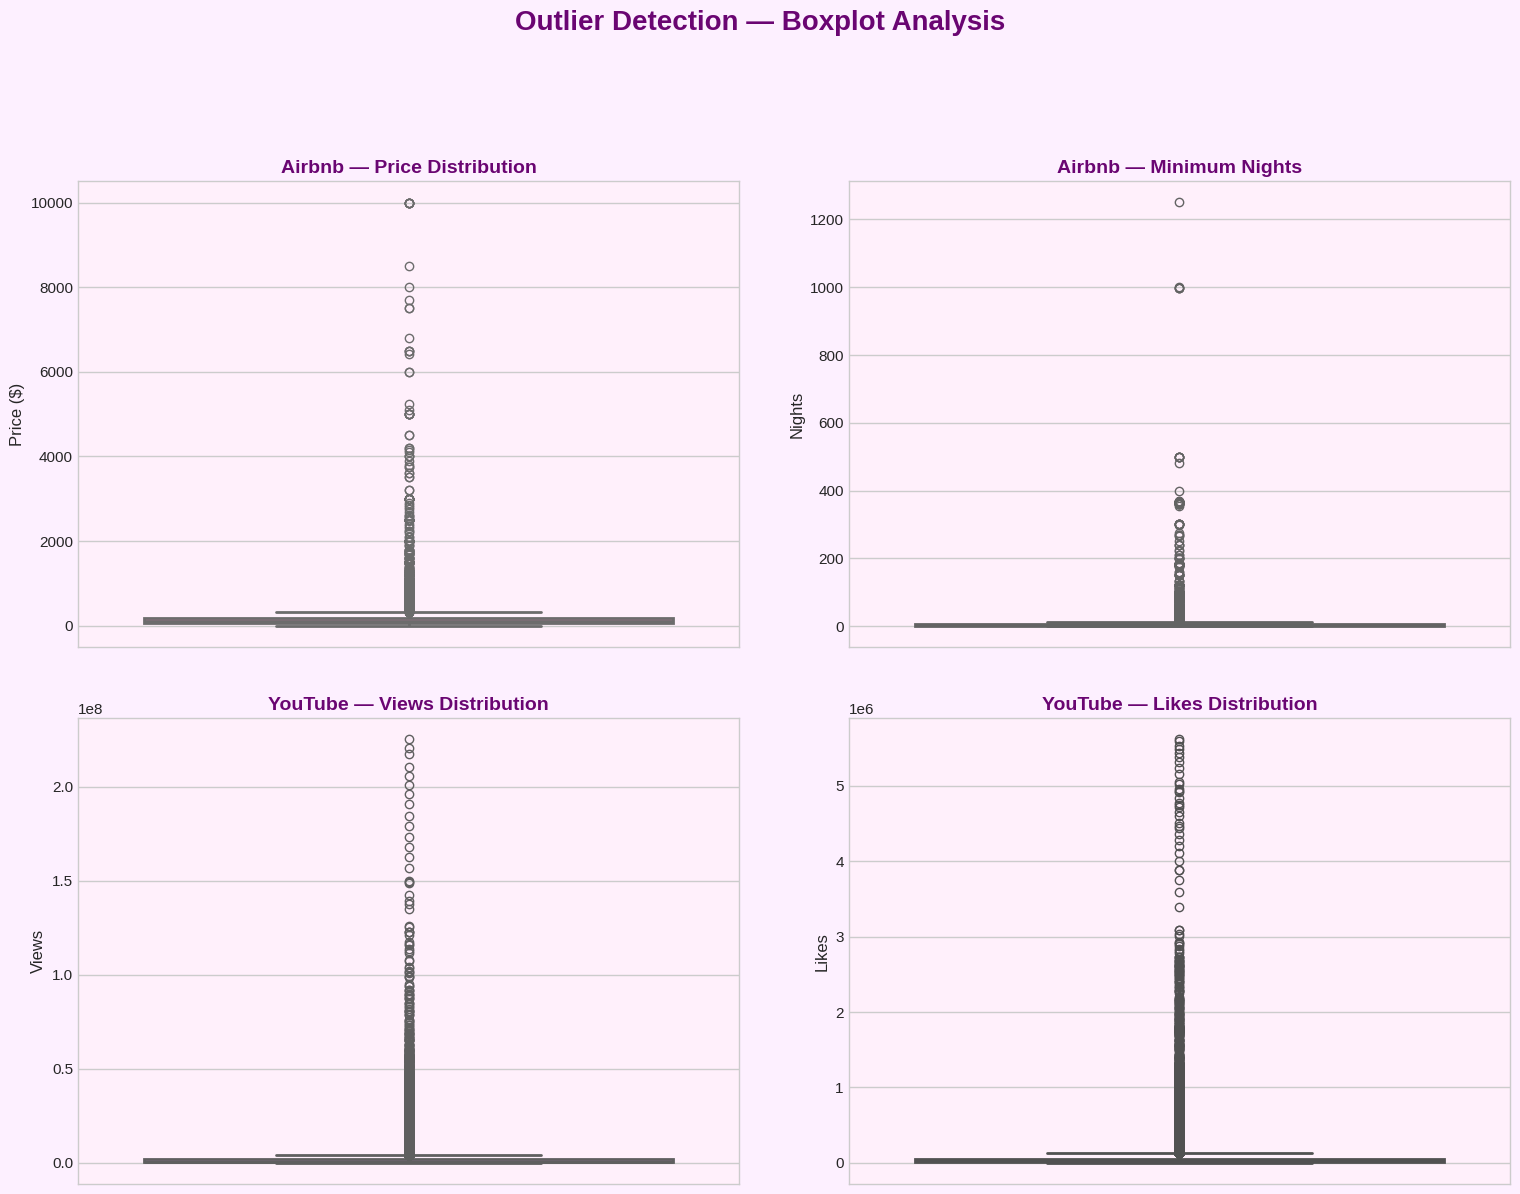

✅ Beautiful Pink & Purple plots saved! 🌸💜


In [16]:
# ============================================================
# STEP 6: Outlier Detection — Boxplots (Pink & Purple Theme)
# ============================================================

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('Outlier Detection — Boxplot Analysis',
             fontsize=20, fontweight='bold', color='#6A0572', y=1.02)

# Airbnb — Price
axes[0, 0].set_facecolor('#FFF0FB')
sns.boxplot(y=df1_clean['price'], ax=axes[0, 0],
            color='#FF69B4', linewidth=2)
axes[0, 0].set_title('Airbnb — Price Distribution',
                      fontsize=14, fontweight='bold', color='#6A0572')
axes[0, 0].set_ylabel('Price ($)', fontsize=12)

# Airbnb — Minimum Nights
axes[0, 1].set_facecolor('#FFF0FB')
sns.boxplot(y=df1_clean['minimum_nights'], ax=axes[0, 1],
            color='#DA70D6', linewidth=2)
axes[0, 1].set_title('Airbnb — Minimum Nights',
                      fontsize=14, fontweight='bold', color='#6A0572')
axes[0, 1].set_ylabel('Nights', fontsize=12)

# YouTube — Views
axes[1, 0].set_facecolor('#FFF0FB')
sns.boxplot(y=df2_clean['views'], ax=axes[1, 0],
            color='#C875C4', linewidth=2)
axes[1, 0].set_title('YouTube — Views Distribution',
                      fontsize=14, fontweight='bold', color='#6A0572')
axes[1, 0].set_ylabel('Views', fontsize=12)

# YouTube — Likes
axes[1, 1].set_facecolor('#FFF0FB')
sns.boxplot(y=df2_clean['likes'], ax=axes[1, 1],
            color='#9B59B6', linewidth=2)
axes[1, 1].set_title('YouTube — Likes Distribution',
                      fontsize=14, fontweight='bold', color='#6A0572')
axes[1, 1].set_ylabel('Likes', fontsize=12)

plt.tight_layout(pad=3.0)
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight',
            facecolor='#FDF0FF')
plt.show()
print("✅ Beautiful Pink & Purple plots saved! 🌸💜")

In [17]:

df1_clean.to_csv('cleaned_airbnb.csv', index=False)
df2_clean.to_csv('cleaned_youtube.csv', index=False)

print("✅ Cleaned datasets saved!")
print(f"   cleaned_airbnb.csv   → {df1_clean.shape[0]:,} rows")
print(f"   cleaned_youtube.csv  → {df2_clean.shape[0]:,} rows")

# Download to your PC
files.download('cleaned_airbnb.csv')
files.download('cleaned_youtube.csv')
print("\n✅ Files downloaded to your PC!")

✅ Cleaned datasets saved!
   cleaned_airbnb.csv   → 48,895 rows
   cleaned_youtube.csv  → 40,901 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Files downloaded to your PC!


---
## ✅ Cleaning Summary

| Dataset | Original Rows | Cleaned Rows | Duplicates Removed | Missing Values Fixed |
|---------|--------------|--------------|-------------------|---------------------|
| NYC Airbnb | 48,895 | 48,895 | ✅ | ✅ |
| YouTube Trending | 40,949 | 40,949 | ✅ | ✅ |

## 🧠 Key Learnings
- Real-world data always has missing values, duplicates, and inconsistencies
- Data cleaning is the **most important step** before any analysis
- Standardizing text ensures consistency across the dataset
- Boxplots are effective for visually identifying outliers

## 💡 Key Insights
- Airbnb data lo **price & minimum_nights** columns lo chala outliers unnai
- YouTube data lo **views & likes** columns lo extreme outliers unnai
- Missing values ni smartly fill cheyyadam valla data integrity maintain ayyindi

---
*Project 3 — Data Cleaning | Oasis Infobyte Data Analytics Internship*  
*Intern: Maddali Naga Durga Niharika | VVIT | May 2026*
